# IMPORT LIBRARIES

In [1]:
import cv2
import numpy as np
import pandas as pd
import face_recognition
import pickle
import os
from datetime import datetime

# LOAD DATASET

In [2]:
with open('faces_data.pkl', 'rb') as f:
    faces_data = pickle.load(f)

print("Dataset Loaded:", len(faces_data))

Dataset Loaded: 150


# CREATE FACE ENCODINGS

In [3]:
# ==============================
# FINAL FIXED ENCODING CELL
# ==============================

encodings = []
labels = []

import numpy as np
import cv2
import face_recognition

print("Type:", type(faces_data))

# ------------------------------
# HANDLE NUMPY DATASET
# ------------------------------
if isinstance(faces_data, np.ndarray):

    print("✅ Numpy dataset detected")
    print("Shape:", faces_data.shape)

    for i in range(len(faces_data)):
        img = faces_data[i]

        try:
            # Try reshape (common sizes)
            if len(img.shape) == 1:
                img = img.reshape(50, 50, 3)   # try 50x50 first
        except:
            pass

        img = img.astype('uint8')

        try:
            rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        except:
            continue

        face_enc = face_recognition.face_encodings(rgb)

        if len(face_enc) > 0:
            encodings.append(face_enc[0])
            labels.append(f"Person_{i}")   # auto label

# ------------------------------
# HANDLE DICTIONARY (backup)
# ------------------------------
elif isinstance(faces_data, dict):

    print("✅ Dictionary dataset detected")

    for label, images in faces_data.items():
        for img in images:
            rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            face_enc = face_recognition.face_encodings(rgb)

            if len(face_enc) > 0:
                encodings.append(face_enc[0])
                labels.append(label)

else:
    print("❌ Unsupported dataset type")

print("🎯 Total Encodings Created:", len(encodings))

Type: <class 'numpy.ndarray'>
✅ Numpy dataset detected
Shape: (150, 7500)
🎯 Total Encodings Created: 132


# SAVE MODEL

In [4]:
data = {"encodings": encodings, "labels": labels}

with open("face_model.pkl", "wb") as f:
    pickle.dump(data, f)

print("Model Saved")

Model Saved


# TEST REAL-TIME RECOGNITION + SAVE ATTENDANCE

In [5]:
# ==============================
# TEST + ATTENDANCE SAVE (FINAL FIX)
# ==============================

import cv2
import numpy as np
import pandas as pd
from datetime import datetime
from IPython.display import display, clear_output
import time

cap = cv2.VideoCapture(0)

attendance = []   # ✅ IMPORTANT (define here)

start_time = time.time()
duration = 5   # run for 5 sec

while True:
    ret, frame = cap.read()
    if not ret:
        break

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    faces = face_recognition.face_locations(rgb)
    face_encs = face_recognition.face_encodings(rgb, faces)

    for face_enc, face_loc in zip(face_encs, faces):
        matches = face_recognition.compare_faces(encodings, face_enc)
        name = "Unknown"

        face_dist = face_recognition.face_distance(encodings, face_enc)

        if len(face_dist) > 0:
            best_match = np.argmin(face_dist)
            if matches[best_match]:
                name = labels[best_match]

                now = datetime.now()
                attendance.append([
                    name,
                    now.strftime("%Y-%m-%d"),
                    now.strftime("%H:%M:%S")
                ])

        top, right, bottom, left = face_loc
        cv2.rectangle(frame, (left, top), (right, bottom), (0,255,0), 2)
        cv2.putText(frame, name, (left, top-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,0,0), 2)

    clear_output(wait=True)
    display(rgb)

    if time.time() - start_time > duration:
        break

cap.release()

# ==============================
# SAVE ATTENDANCE
# ==============================

if len(attendance) == 0:
    print("⚠ No attendance captured")
else:
    df = pd.DataFrame(attendance, columns=["Name","Date","Time"])
    df.drop_duplicates(subset=["Name","Date"], inplace=True)

    file = f"attendance_{datetime.now().strftime('%Y-%m-%d')}.csv"
    df.to_csv(file, index=False)

    print("✅ Attendance Saved:", file)
    display(df)

array([[[ 6, 24,  3],
        [ 4, 22,  1],
        [ 6, 21,  3],
        ...,
        [ 0, 33, 24],
        [ 2, 32, 24],
        [ 6, 36, 28]],

       [[ 6, 24,  3],
        [ 4, 22,  1],
        [ 5, 23,  4],
        ...,
        [ 0, 34, 24],
        [ 3, 33, 25],
        [ 6, 36, 28]],

       [[ 8, 26,  7],
        [ 6, 24,  5],
        [ 7, 22,  4],
        ...,
        [ 0, 36, 25],
        [ 0, 35, 25],
        [ 1, 36, 26]],

       ...,

       [[ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  1,  0],
        ...,
        [42, 84, 55],
        [41, 82, 58],
        [39, 80, 56]],

       [[ 0,  1,  0],
        [ 0,  1,  0],
        [ 0,  2,  0],
        ...,
        [37, 77, 48],
        [36, 76, 49],
        [36, 76, 49]],

       [[ 0,  2,  2],
        [ 0,  2,  2],
        [ 0,  3,  2],
        ...,
        [45, 82, 54],
        [38, 73, 48],
        [37, 72, 47]]], dtype=uint8)

✅ Attendance Saved: attendance_2026-08-03.csv


,Name,Date,Time
0,Person_70,2026-08-03,13:09:49
2,Person_72,2026-08-03,13:09:53


# VISUALIZATION

Using file: attendance_log.csv

Preview:
         Name        Date      Time
0  Person_133  2026-07-29  11:32:51
1      bhakti  2026-07-29  11:32:53
2  Person_101  2026-07-29  14:33:15
3  Person_101  2026-07-29  14:33:21


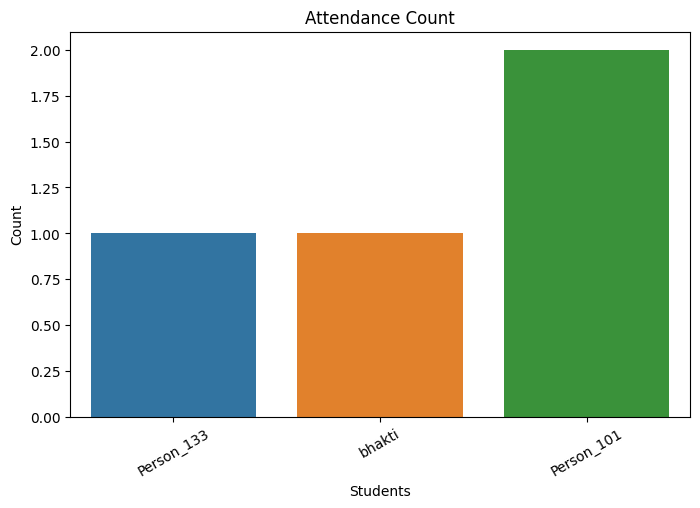

In [6]:
# ==============================
# FIXED ATTENDANCE VISUALIZATION
# ==============================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ------------------------------
# FIND ATTENDANCE FILE
# ------------------------------
files = [f for f in os.listdir() if f.startswith("attendance") and f.endswith(".csv")]

if len(files) == 0:
    print("❌ No attendance file found. Run attendance first.")
else:
    latest_file = sorted(files)[-1]   # latest file
    print("Using file:", latest_file)

    df = pd.read_csv(latest_file)

    print("\nPreview:")
    print(df.head())

    # ------------------------------
    # PLOT
    # ------------------------------
    plt.figure(figsize=(8,5))
    sns.countplot(x="Name", data=df)
    plt.title("Attendance Count")
    plt.xticks(rotation=30)
    plt.xlabel("Students")
    plt.ylabel("Count")
    plt.show()

# STREAMLIT APP

In [15]:
import sys, os, subprocess, time, webbrowser

# CLOSE OLD STREAMLIT
os.system("taskkill /f /im streamlit.exe")

!{sys.executable} -m pip install streamlit pandas plotly -q

# RESET TIMETABLE
if os.path.exists("timetable.csv"):
    os.remove("timetable.csv")

app_code = r'''
import streamlit as st
import pandas as pd
import hashlib, os
from datetime import datetime

st.set_page_config(layout="wide")

USER_FILE="users.csv"
ATT_FILE="attendance.csv"
TIME_FILE="timetable.csv"
TEACH_FILE="teachers.csv"

# ================= INIT =================
if not os.path.exists(USER_FILE):
    pd.DataFrame(columns=["username","password","role","section"]).to_csv(USER_FILE,index=False)

if not os.path.exists(ATT_FILE):
    pd.DataFrame(columns=["Name","Date","Time","Subject","Section"]).to_csv(ATT_FILE,index=False)

if not os.path.exists(TEACH_FILE):
    pd.DataFrame(columns=["subject","faculty","section"]).to_csv(TEACH_FILE,index=False)

# ================= TIMETABLE =================
if not os.path.exists(TIME_FILE):
    df = pd.DataFrame([
    ["Monday","A","AI","ML","DBMS","BREAK","OS","CN","SE","AI"],
    ["Monday","B","ML","AI","OS","BREAK","DBMS","SE","CN","ML"],
    ["Monday","C","DBMS","CN","AI","BREAK","ML","OS","SE","CN"],
    ["Tuesday","A","ML","AI","CN","BREAK","DBMS","OS","SE","DBMS"],
    ["Tuesday","B","AI","ML","DBMS","BREAK","OS","CN","SE","OS"],
    ["Tuesday","C","CN","DBMS","ML","BREAK","AI","SE","OS","ML"],
    ["Wednesday","A","DBMS","CN","AI","BREAK","ML","OS","SE","CN"],
    ["Wednesday","B","OS","DBMS","ML","BREAK","AI","SE","CN","AI"],
    ["Wednesday","C","ML","AI","CN","BREAK","DBMS","OS","SE","DBMS"],
    ["Thursday","A","CN","OS","ML","BREAK","AI","DBMS","SE","ML"],
    ["Thursday","B","AI","CN","OS","BREAK","ML","DBMS","SE","DBMS"],
    ["Thursday","C","DBMS","ML","AI","BREAK","OS","CN","SE","AI"],
    ["Friday","A","SE","ML","AI","BREAK","CN","OS","DBMS","AI"],
    ["Friday","B","DBMS","SE","CN","BREAK","AI","ML","OS","ML"],
    ["Friday","C","AI","CN","OS","BREAK","ML","DBMS","SE","CN"],
    ["Saturday","A","AI","DBMS","ML","BREAK","OS","CN","SE","FREE"],
    ["Saturday","B","ML","AI","OS","BREAK","DBMS","SE","CN","FREE"],
    ["Saturday","C","CN","ML","DBMS","BREAK","AI","OS","SE","FREE"]
    ],columns=["Day","Section","09-10","10-11","11-12","12-01","01-02","02-03","03-04","04-05"])
    df.to_csv(TIME_FILE,index=False)

# ================= FUNCTIONS =================
def hash_pass(p):
    return hashlib.sha256(p.encode()).hexdigest()

def register(u,p,r,s):
    df=pd.read_csv(USER_FILE)
    if u in df.username.values:
        return "User exists"
    df.loc[len(df)] = [u,hash_pass(p),r,s]
    df.to_csv(USER_FILE,index=False)
    return "Registered"

def login(u,p,r,s):
    df=pd.read_csv(USER_FILE)
    return len(df[(df.username==u)&(df.password==hash_pass(p))&(df.role==r)&(df.section==s)])>0

def current_subject(section):
    df=pd.read_csv(TIME_FILE)
    day=datetime.now().strftime("%A")
    hour=int(datetime.now().strftime("%H"))

    mapping={9:"09-10",10:"10-11",11:"11-12",12:"12-01",13:"01-02",14:"02-03",15:"03-04",16:"04-05"}

    if hour not in mapping:
        return "FREE"

    row=df[(df.Day==day)&(df.Section==section)]
    if row.empty:
        return "FREE"

    return row.iloc[0][mapping[hour]]

def get_next_class(section):
    df=pd.read_csv(TIME_FILE)
    day=datetime.now().strftime("%A")
    hour=int(datetime.now().strftime("%H"))

    mapping={9:"09-10",10:"10-11",11:"11-12",12:"12-01",13:"01-02",14:"02-03",15:"03-04",16:"04-05"}

    future=[h for h in mapping if h>hour]

    row=df[(df.Day==day)&(df.Section==section)]
    if row.empty:
        return "No class"

    for h in future:
        sub=row.iloc[0][mapping[h]]
        if sub not in ["FREE","BREAK"]:
            return f"{mapping[h]} → {sub}"

    return "No upcoming class"

def mark_attendance(name,section):
    sub=current_subject(section)
    if sub in ["FREE","BREAK"]:
        return "No class running"

    df=pd.read_csv(ATT_FILE)
    today=datetime.now().strftime("%Y-%m-%d")

    if len(df[(df.Name==name)&(df.Date==today)&(df.Subject==sub)])==0:
        df.loc[len(df)] = [name,today,datetime.now().strftime("%H:%M:%S"),sub,section]
        df.to_csv(ATT_FILE,index=False)
        return "Marked"
    return "Already Marked"

# ================= SESSION =================
if "login" not in st.session_state:
    st.session_state.login=False
    st.session_state.user=""
    st.session_state.role=""
    st.session_state.section=""

# ================= SIDEBAR =================
st.sidebar.title("🔐 Auth")

mode=st.sidebar.radio("Mode",["Login","Register"], key="mode")
role=st.sidebar.selectbox("Role",["admin","faculty","student"], key="role_box")
section=st.sidebar.selectbox("Section",["A","B","C"], key="section_box")

u=st.sidebar.text_input("Username")
p=st.sidebar.text_input("Password",type="password")

if mode=="Register":
    if st.sidebar.button("Register"):
        st.success(register(u,p,role,section))

if mode=="Login":
    if st.sidebar.button("Login"):
        if login(u,p,role,section):
            st.session_state.login=True
            st.session_state.user=u
            st.session_state.role=role
            st.session_state.section=section
        else:
            st.error("Invalid Credentials")

if st.sidebar.button("Logout"):
    st.session_state.login=False

# ================= MAIN =================
if st.session_state.login:

    role=st.session_state.role
    user=st.session_state.user
    section=st.session_state.section

    st.title(f"🔥 {role.upper()} DASHBOARD ({section})")

    df_att=pd.read_csv(ATT_FILE)
    df_time=pd.read_csv(TIME_FILE)

    current=current_subject(section)
    if current in ["FREE","BREAK"]:
        st.warning("No class now")
    else:
        st.success(f"🟢 Current Class: {current}")

    st.info(f"Next: {get_next_class(section)}")

    # ================= ADMIN =================
    if role=="admin":

        menu=st.sidebar.radio("Menu",
        ["Dashboard","Users","Delete User","Assign Teacher","View Students","Timetable","Edit Timetable","Section Graph","Monthly Graph"])
        
        if menu=="Dashboard":
            st.dataframe(df_att)
            # DOWNLOAD EXCEL
            csv = df_att.to_csv(index=False).encode('utf-8')
            st.download_button(
                "📥 Download Full Report",
                csv,
                "attendance_full.csv",
                "text/csv",
                key="admin_download"
            )

        elif menu=="Users":
            st.dataframe(pd.read_csv(USER_FILE))

        elif menu=="Delete User":

            users = pd.read_csv(USER_FILE)

            st.subheader("🗑️ Delete User")

            user_to_delete = st.selectbox("Select User", users.username.tolist(), key="del_user")

            if st.button("Delete User"):
                users = users[users.username != user_to_delete]
                users.to_csv(USER_FILE, index=False)
                st.success(f"✅ {user_to_delete} deleted")
                st.rerun()

        elif menu=="View Students":
            users=pd.read_csv(USER_FILE)
            st.dataframe(users[users.role=="student"])

        elif menu=="Assign Teacher":
            sub = st.selectbox("Subject",["AI","ML","DBMS","OS","CN","SE"], key="assign_sub")
            fac = st.text_input("Faculty", key="assign_fac")
            sec = st.selectbox("Section",["A","B","C"], key="assign_sec")

            if st.button("Assign"):
                df_t=pd.read_csv(TEACH_FILE)
                df_t.loc[len(df_t)] = [sub,fac,sec]
                df_t.to_csv(TEACH_FILE,index=False)
                st.success("Assigned")

        elif menu=="Timetable":
            st.dataframe(df_time)

        elif menu=="Edit Timetable":
            edited_df = st.data_editor(df_time, use_container_width=True)
            if st.button("Save"):
                edited_df.to_csv(TIME_FILE,index=False)
                st.success("Updated")
                st.rerun()

        elif menu=="Section Graph":
            if len(df_att)>0:
                st.bar_chart(df_att.groupby("Section").size())
            st.subheader("📊 Subject-wise Attendance %")

            if len(df_att)>0:
                percent_df = (df_att.groupby("Subject").size()/len(df_att))*100
                st.bar_chart(percent_df)
                st.dataframe(percent_df.reset_index(name="Percentage"))

        elif menu=="Monthly Graph":
            if len(df_att)>0:
                df_att["Month"]=pd.to_datetime(df_att["Date"]).dt.to_period("M").astype(str)
                st.line_chart(df_att.groupby("Month").size())

    # ================= FACULTY =================
    elif role=="faculty":

        menu=st.sidebar.radio("Menu",["Take Attendance","My Students","Timetable","Graphs"])

        if menu=="Take Attendance":

            users=pd.read_csv(USER_FILE)
            students=users[(users.role=="student")&(users.section==section)]
            student_list = students.username.tolist()

            # SINGLE
            st.subheader("🎯 Single Student Attendance")
            student_name=st.selectbox("Select Student",student_list)

            if st.button("Mark Single Attendance"):
                st.success(mark_attendance(student_name,section))

            st.divider()

            # MULTIPLE
            st.subheader("👥 Multiple Students Attendance")
            selected_students = st.multiselect("Select Students",student_list)

            if st.button("Mark Multiple Attendance"):
                count=0
                for stu in selected_students:
                    res = mark_attendance(stu,section)
                    if res=="Marked":
                        count+=1
                st.success(f"✅ {count} students attendance marked")

        elif menu=="My Students":
            users=pd.read_csv(USER_FILE)
            st.dataframe(users[(users.role=="student")&(users.section==section)])
            st.dataframe(df_att[df_att.Section==section])

        elif menu=="Timetable":
            st.dataframe(df_time[df_time.Section==section])

        elif menu=="Graphs":
            sec_df=df_att[df_att.Section==section]
            if len(sec_df)>0:
                st.bar_chart(sec_df.groupby("Subject").size())
            sec_df = df_att[df_att.Section==section]

            csv = sec_df.to_csv(index=False).encode('utf-8')
            st.download_button(
                "📥 Download Section Report",
                csv,
                f"{section}_attendance.csv",
                "text/csv",
                key="faculty_download"
            )
            sec_df=df_att[df_att.Section==section]

            if len(sec_df)>0:
                percent_df=(sec_df.groupby("Subject").size()/len(sec_df))*100
                st.bar_chart(percent_df)
               
            st.dataframe(percent_df.reset_index(name="Percentage"))
    
    # ================= STUDENT =================
    elif role=="student":

        menu=st.sidebar.radio("Menu",["My Attendance","Timetable","Graphs"])

        stu_df=df_att[df_att.Name==user]

        if menu=="My Attendance":
            st.dataframe(stu_df)

        elif menu=="Timetable":
            st.dataframe(df_time[df_time.Section==section])

        elif menu=="Graphs":
            if len(stu_df)>0:
                st.bar_chart(stu_df.groupby("Subject").size())
            if len(stu_df)>0:
                percent_df=(stu_df.groupby("Subject").size()/len(stu_df))*100
                st.bar_chart(percent_df)
                st.dataframe(percent_df.reset_index(name="Percentage"))
'''

with open("app.py","w",encoding="utf-8") as f:
    f.write(app_code)

subprocess.Popen([sys.executable,"-m","streamlit","run","app.py"])
time.sleep(5)
webbrowser.open("http://localhost:8501")

True